## Exercise 2 — In Silico Microbial Community Simulation

### Model definition

The generalized Lotka–Volterra (gLV) model with external perturbations:

$$\dot{x}_i = x_i \left( r_i + \sum_{j=1}^n A_{ij}\, x_j + \sum_{k=1}^p B_{ik}\, u_k(t) \right), \quad i = 1, \ldots, n$$

**Matrix-vector form.** Let $X = \operatorname{diag}(\mathbf{x}) \in \mathbb{R}^{n \times n}$:

$$\dot{\mathbf{x}} = X\bigl(\mathbf{r} + A\mathbf{x} + B\mathbf{u}(t)\bigr)$$

**Parameters:**
- $\mathbf{r} \in \mathbb{R}^n$ — intrinsic growth rates
- $A \in \mathbb{R}^{n \times n}$ — interaction matrix ($A_{ii}$ self-limitation; $A_{ij}$ inter-taxon effect of $j$ on $i$)
- $B \in \mathbb{R}^{n \times p}$ — perturbation susceptibility
- $\mathbf{u}(t) \in \{0,1\}^p$ — binary perturbation signal (is antibiotic class $k$ active at time $t$?)

### Synthetic parameters

Use $n = 4$ taxa and $p = 1$ antibiotic perturbation:

$$\mathbf{r} = \begin{pmatrix} 0.8 \\ 0.6 \\ 0.4 \\ 1.2 \end{pmatrix}, \qquad
A = \begin{pmatrix}
-1.0 & -0.2 & 0    & 0    \\
-0.1 & -0.8 & -0.3 & 0    \\
 0   & -0.1 & -0.9 & -0.2 \\
 0   &  0   & -0.1 & -1.5
\end{pmatrix}, \qquad
B = \begin{pmatrix} -2.0 \\ -1.5 \\ -1.8 \\ 0.2 \end{pmatrix}$$

**Initial condition:** $\mathbf{x}(0) = (0.3,\ 0.25,\ 0.25,\ 0.2)^\top$

**Perturbation schedule:** $u(t) = 1$ for $t \in [5, 12]$, else $0$.

Numerically integrate the ODE over $t \in [0, 30]$ using `scipy.integrate.solve_ivp`. Plot
all four taxon trajectories with the antibiotic window shaded. Does the community return to
its pre-perturbation equilibrium after $u$ is removed? Repeat with $B_{4,1} = -2.0$ and
compare the post-perturbation recovery.

---


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.integrate import solve_ivp

plt.rcParams["figure.dpi"] = 500
plt.rcParams["savefig.dpi"] = 500

## Simple starting ODE to test out solve_ivp

Success status: True


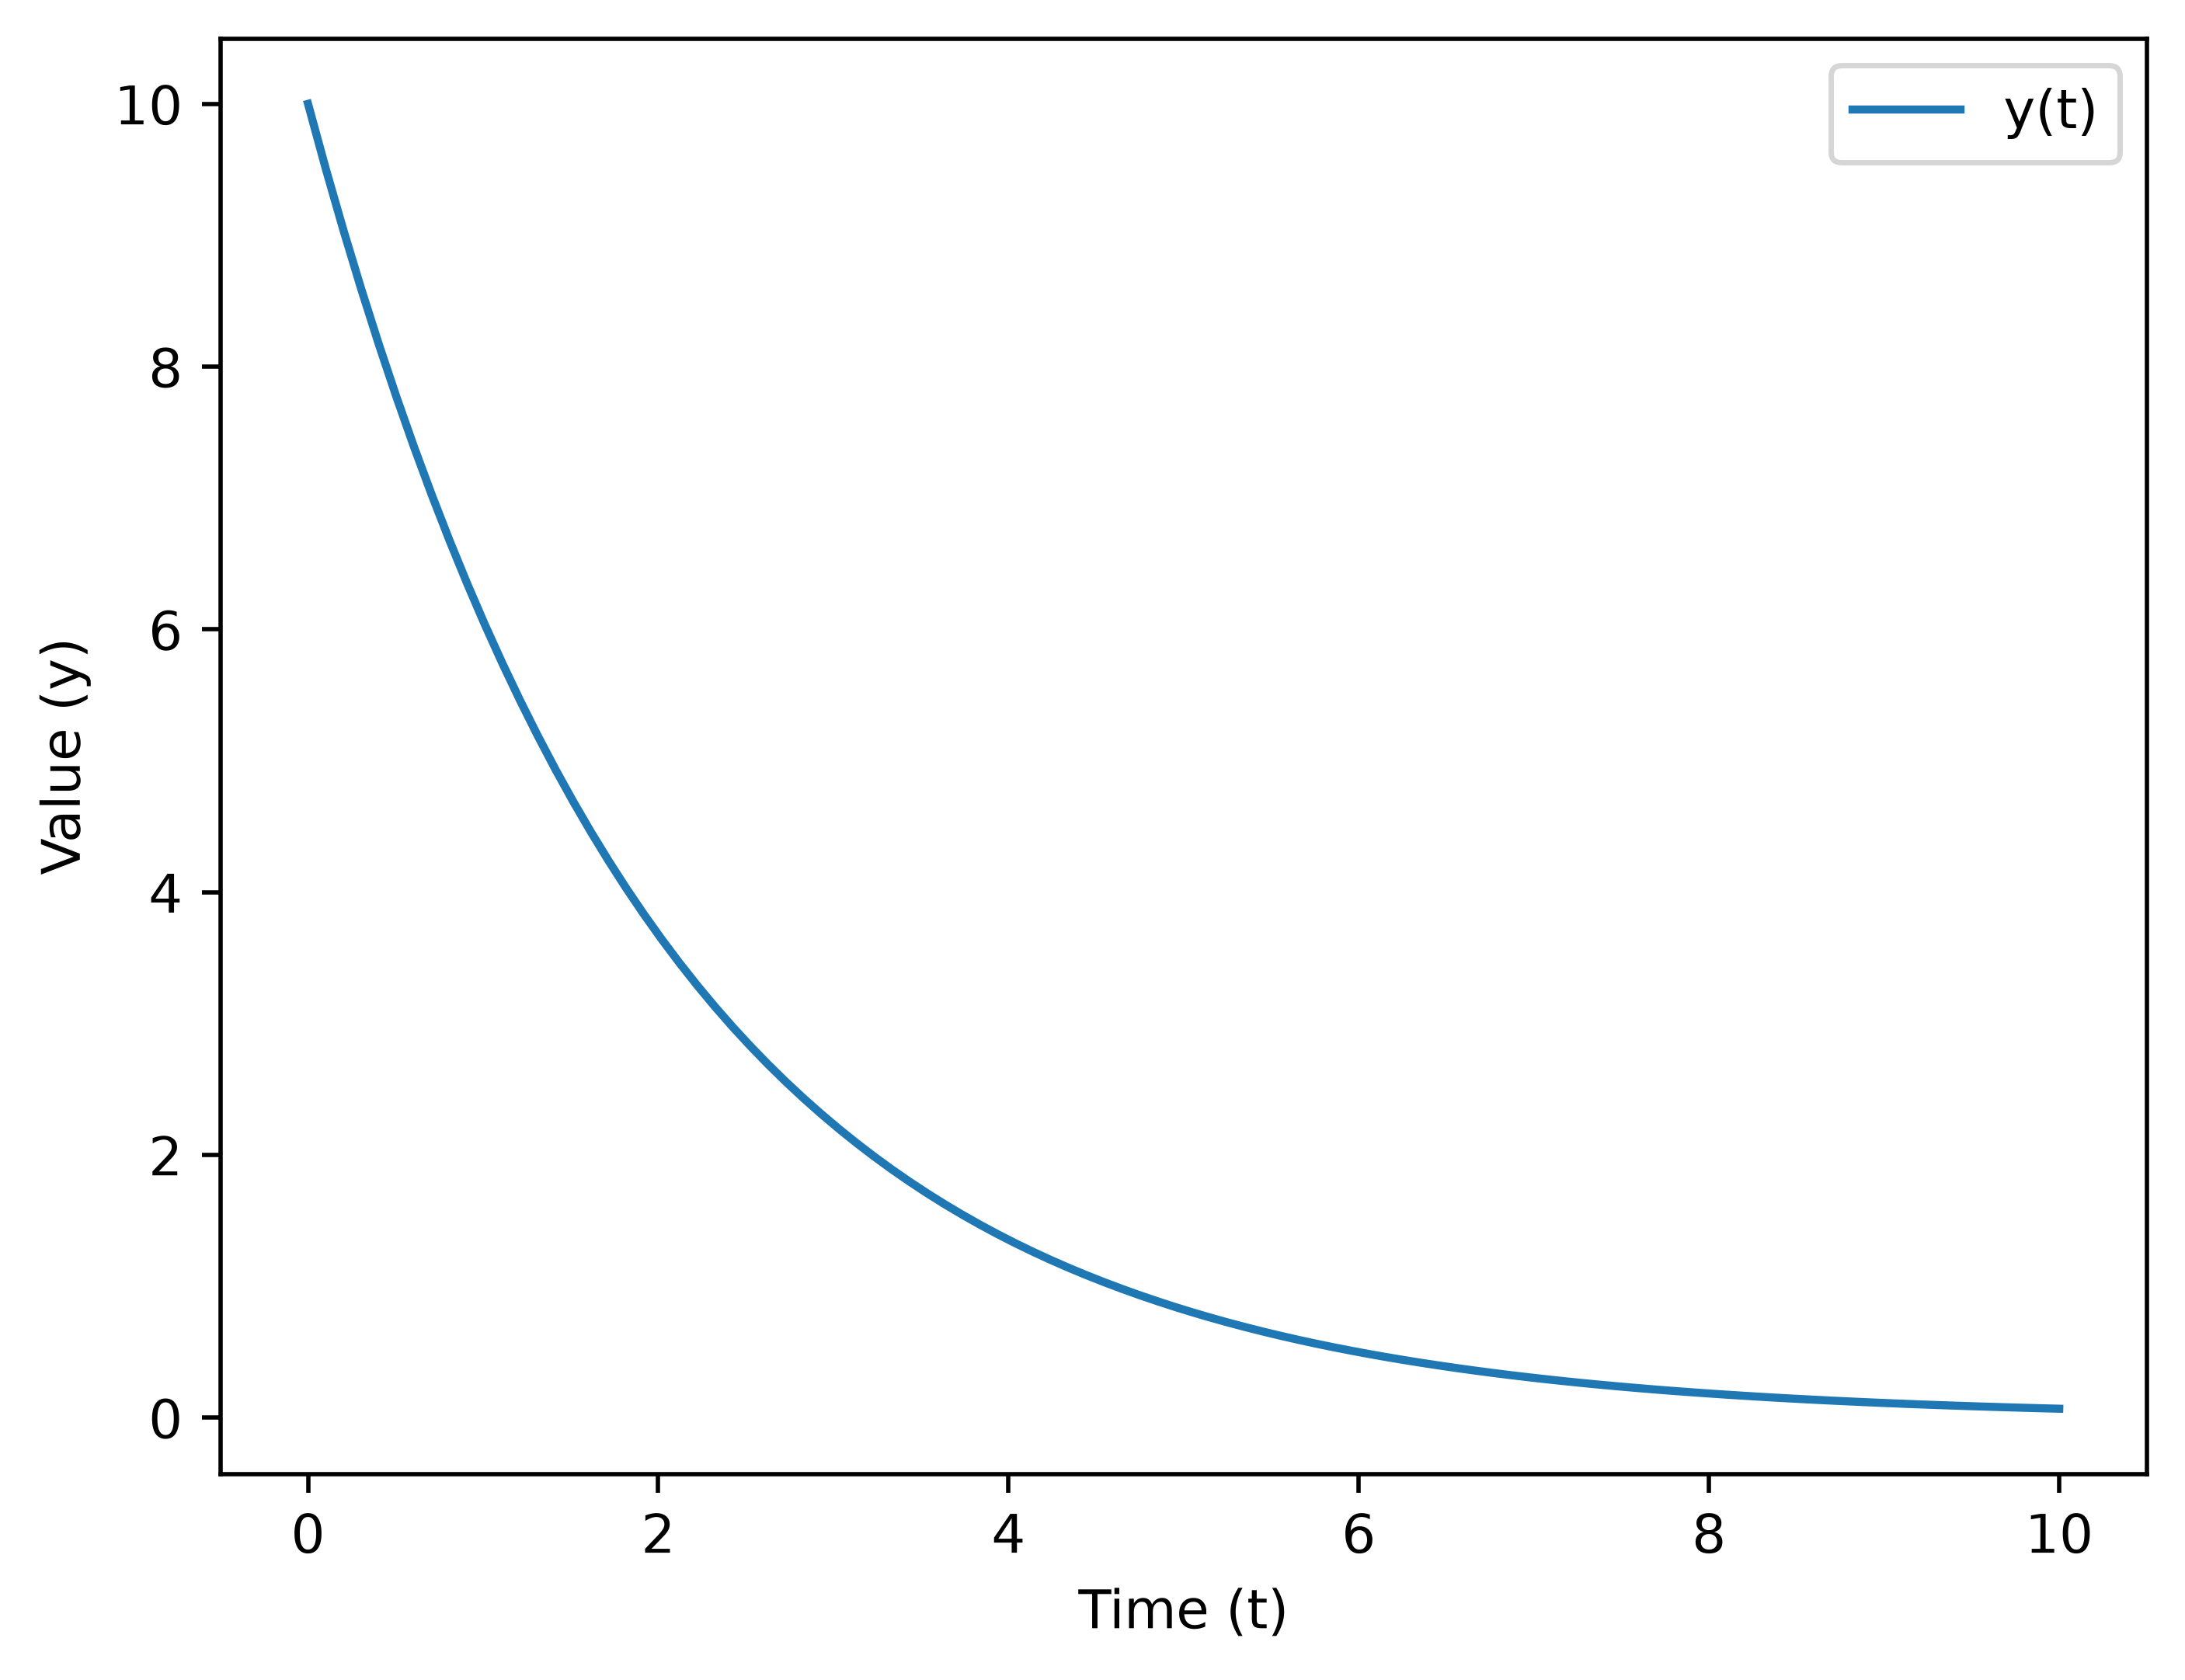

In [7]:
def decay(t, y, k):
    return -k * y

k_constant = 0.5
t_span = (0, 10)    # Start and end time
y0 = [10.0]

# 2. Run the solver
# We pass extra constants (like k) using the 'args' tuple
solution = solve_ivp(decay, t_span, y0, args=(k_constant,), t_eval=np.linspace(0, 10, 100))

# 3. Extract and plot results
print(f"Success status: {solution.success}")

plt.plot(solution.t, solution.y[0], label="y(t)")
plt.xlabel("Time (t)")
plt.ylabel("Value (y)")
plt.legend()
plt.show()

## Testing using multiple variables

In [8]:
# 1. Define the system
def lorenz(t, state, sigma, rho, beta):
    x, y, z = state  # Unpack the current state vector
    
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    
    return [dxdt, dydt, dzdt]  # Return as a list of derivatives

# Constants and conditions
sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0
t_span = (0, 40)
initial_state = [1.0, 1.0, 1.0]  # x0, y0, z0
t_points = np.linspace(0, 40, 4000)

# 2. Solve
sol = solve_ivp(lorenz, t_span, initial_state, args=(sigma, rho, beta), t_eval=t_points)

# 3. Access the data
# sol.y will be a 2D array of shape (number of variables, number of time points)
x_val = sol.y[0]
y_val = sol.y[1]
z_val = sol.y[2]

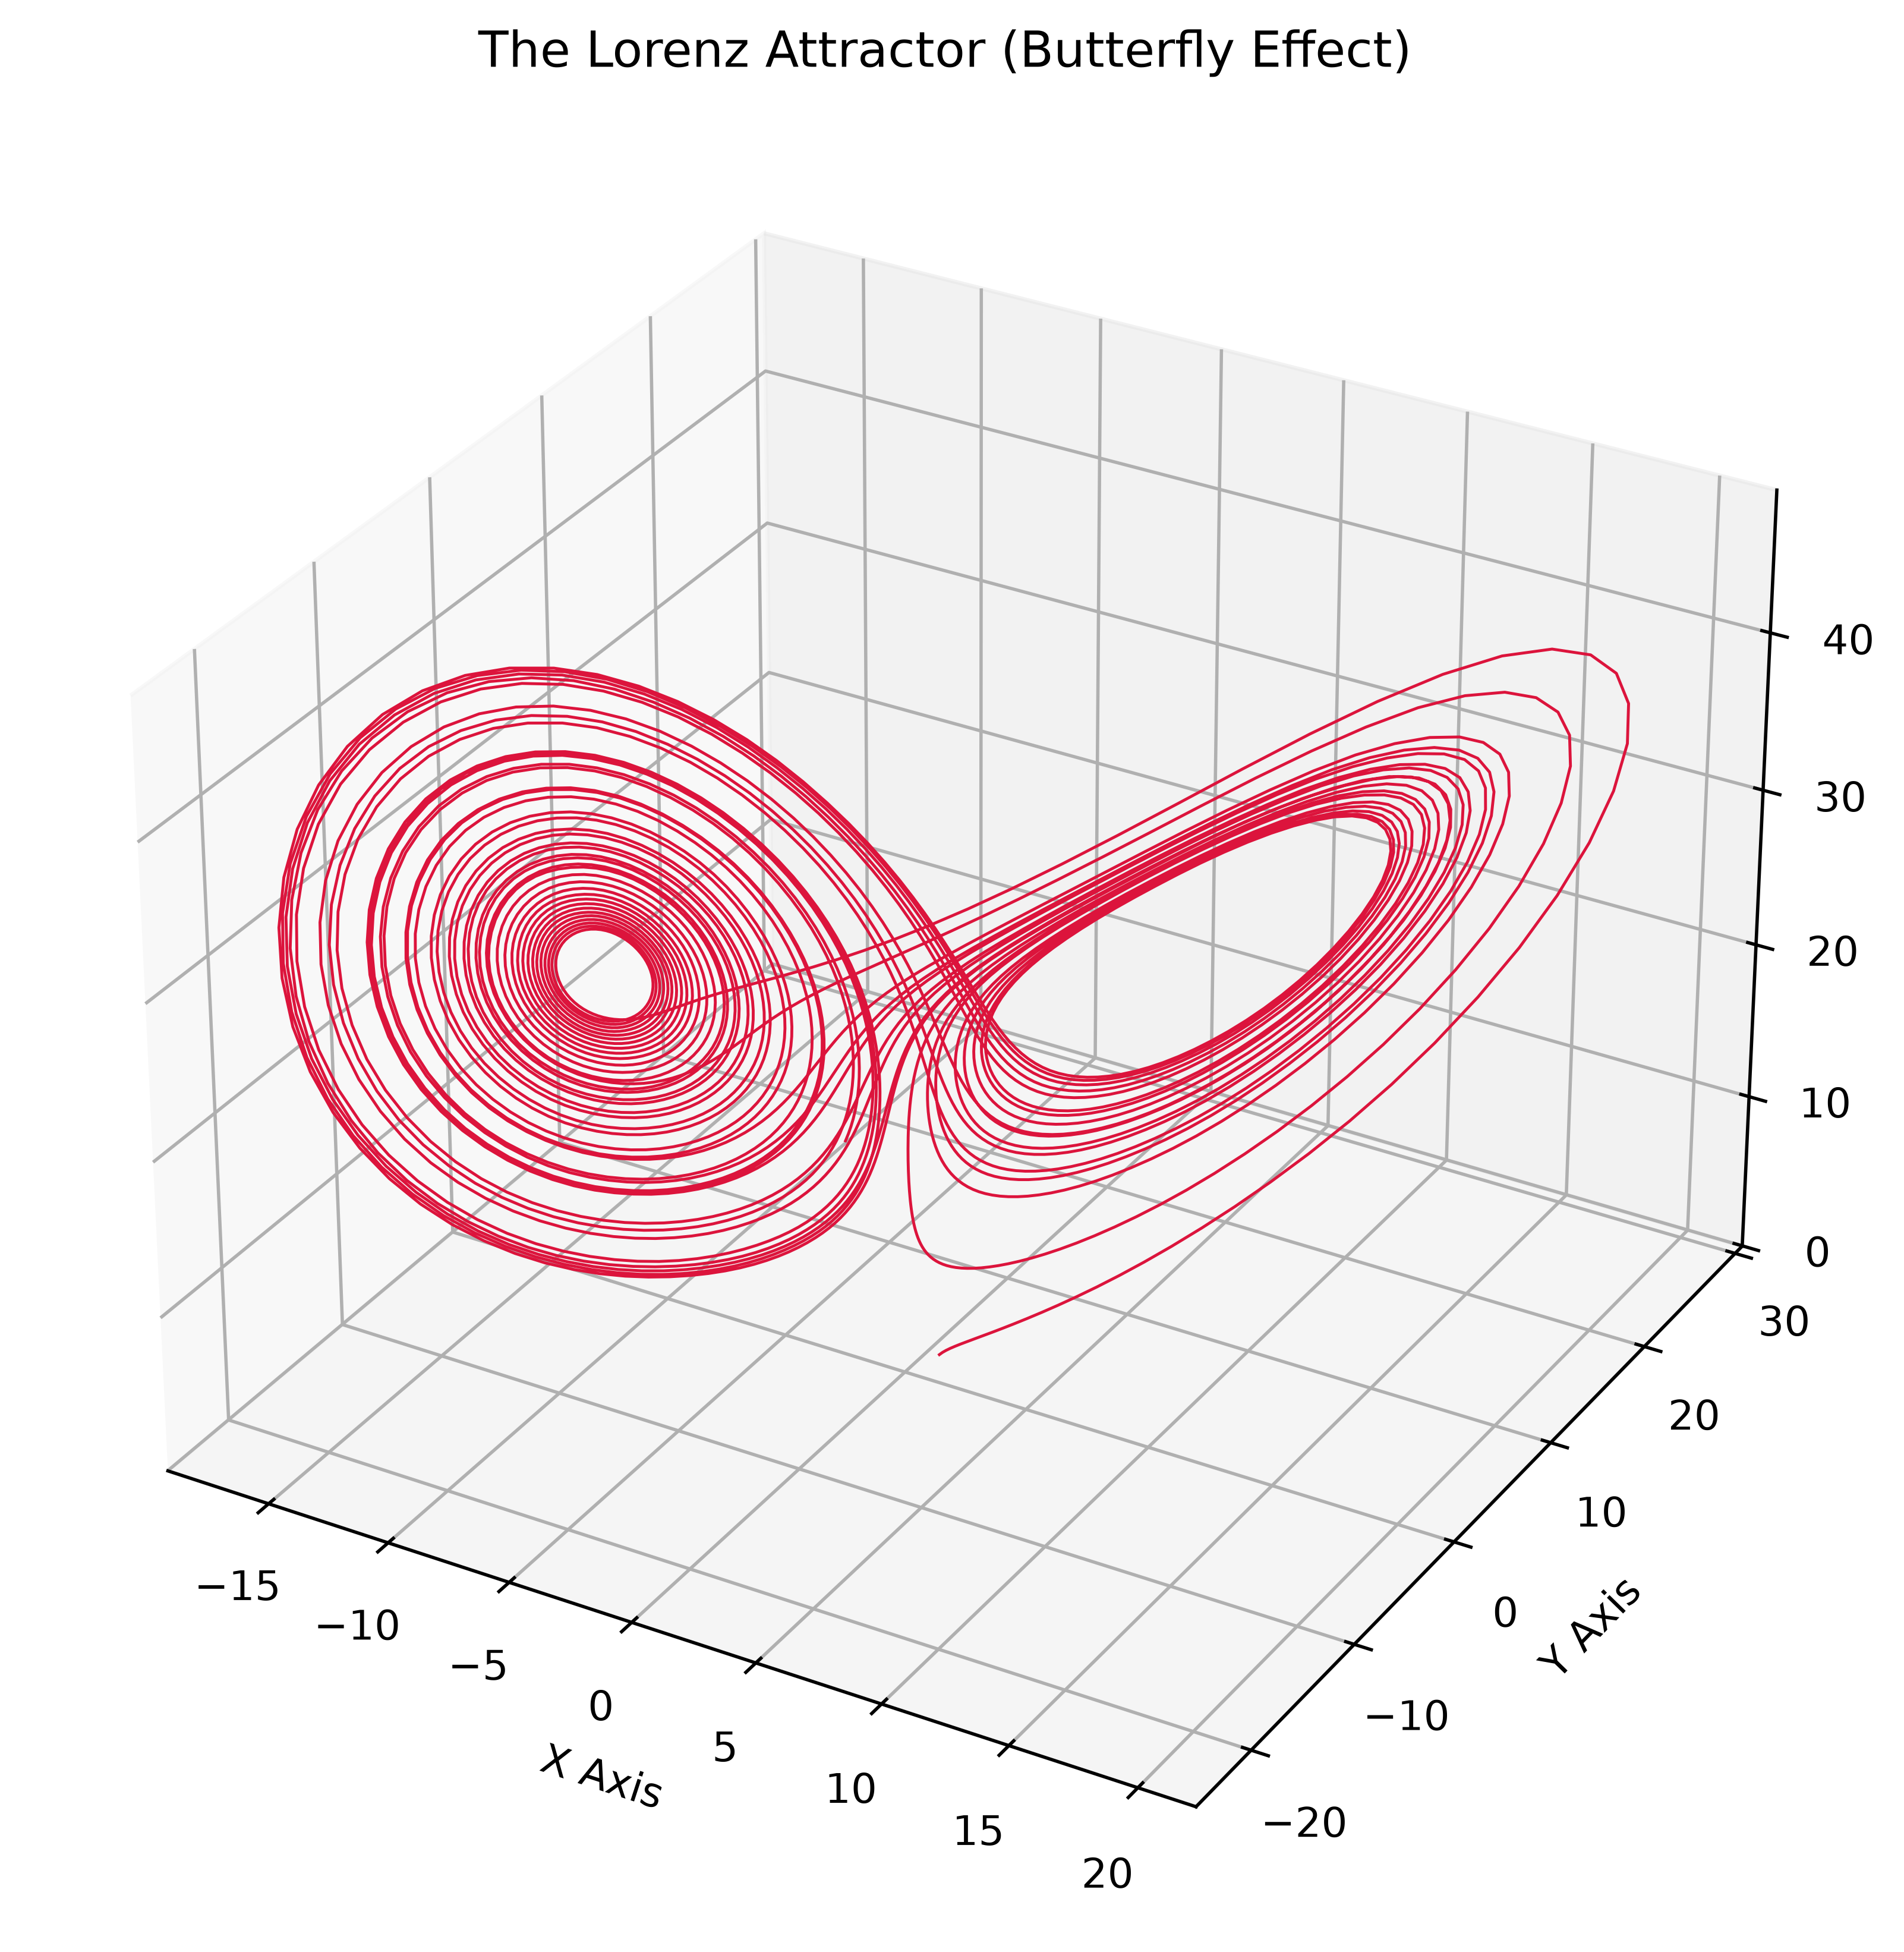

In [9]:

# Plotting:

# 1. Initialize a 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

# 2. Plot the trajectory
# 'lw' sets the line width. A thinner line makes the intricate loops easier to see.
ax.plot(x_val, y_val, z_val, lw=0.7, color='crimson')

# 3. Label the axes so it's readable
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("The Lorenz Attractor (Butterfly Effect)")

# 4. Make it look sleek
ax.set_facecolor('white')  # Clean background
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Show the masterpiece
plt.show()

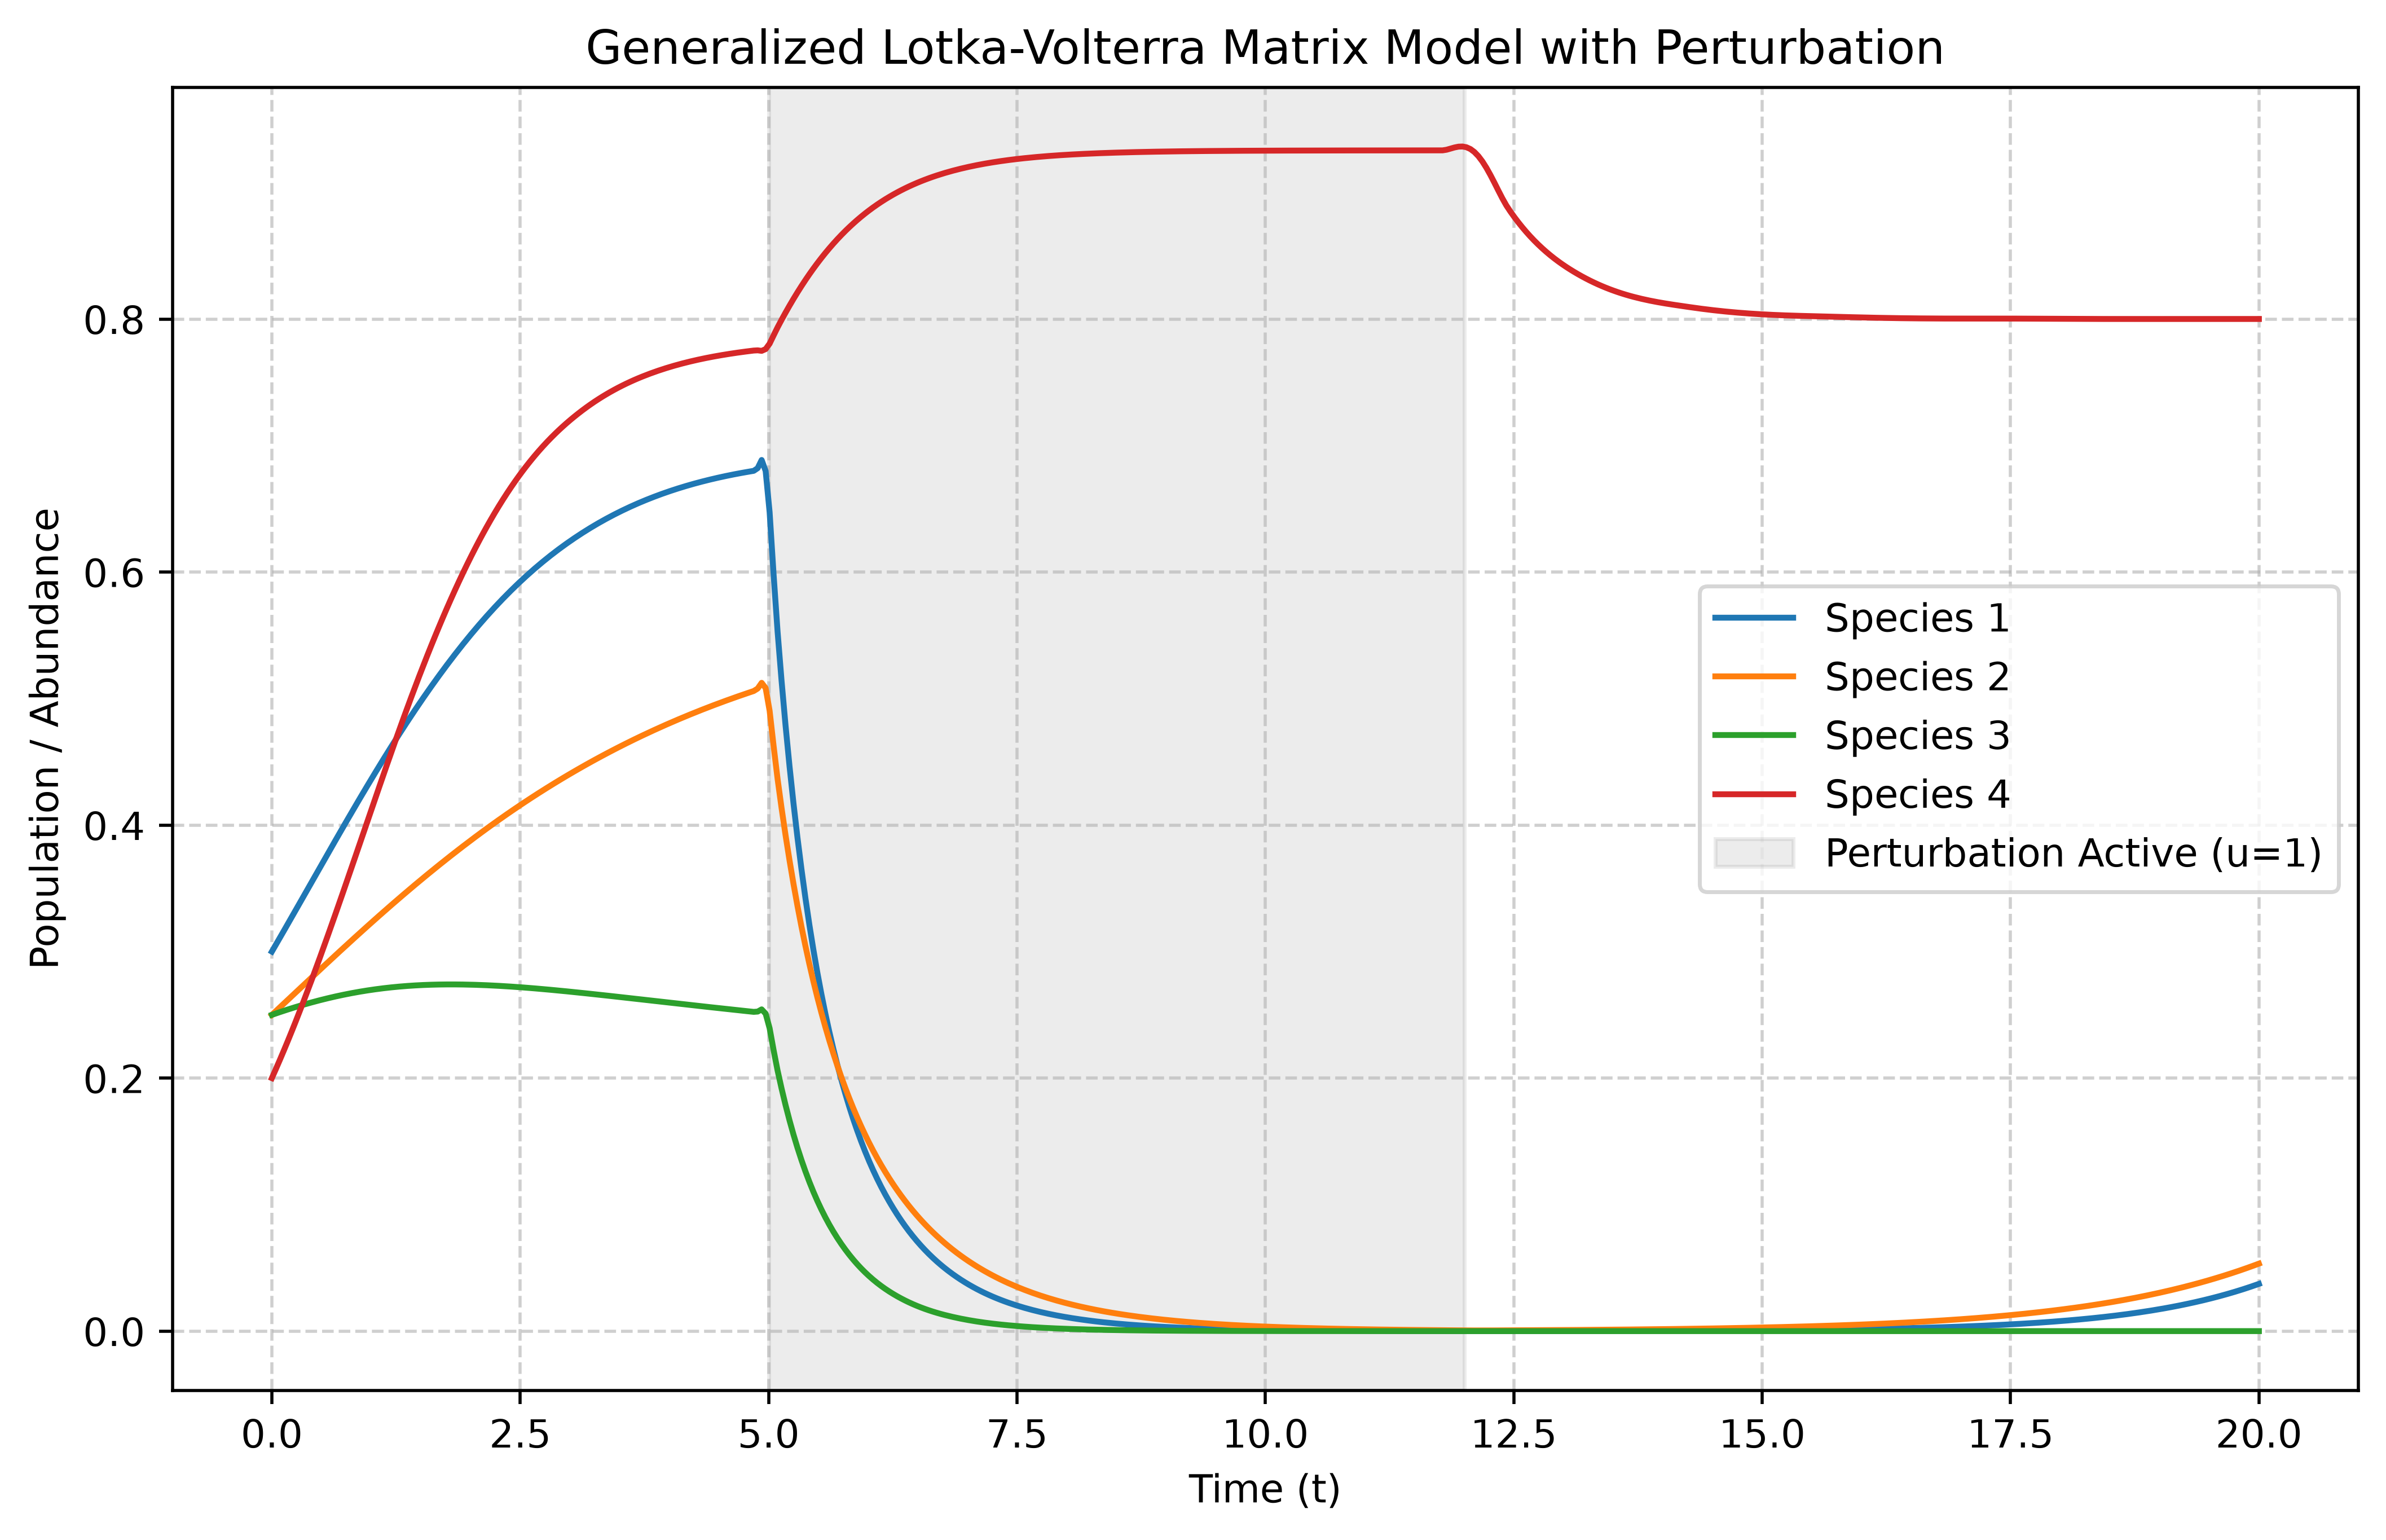

In [10]:
r_growth = np.array([
    0.8,
    0.6,
    0.4,
    1.2
])

A = np.array([
    [ -1.0,  -0.2,  0.0,  0.0],
    [-0.1, -0.8,  -0.3,  0.0],
    [ 0.0,  -0.1,  -0.9,  -0.2],
    [ 0.0,  0.0, -0.1, -1.5]
])

B = np.array(
    [-2.0,
    -1.5,
    -1.8,
    0.2]
)

# Initial conditions
x_init = np.array([
    0.3,
    0.25,
    0.25,
    0.2
])


def x_prime(t, x, r, A, B):
    u = 1.0 if 5 <= t <= 12 else 0.0

    dxdt = x * (r + A @ x + B * u)
    return dxdt

# 3. Simulation parameters
t_span = (0, 20)
t_eval = np.linspace(0, 20, 500)

# 4. Solve the IVP
# We pass r, A, and B through the args tuple
sol = solve_ivp(
    x_prime, 
    t_span, 
    x_init, 
    args=(r_growth, A, B), 
    t_eval=t_eval
)

# 5. Plot results to see the effect of the perturbation
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(sol.t, sol.y[i], label=f"Species {i+1}")

# Highlight the perturbation window
plt.axvspan(5, 12, color='gray', alpha=0.15, label='Perturbation Active (u=1)')

plt.title("Generalized Lotka-Volterra Matrix Model with Perturbation")
plt.xlabel("Time (t)")
plt.ylabel("Population / Abundance")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Now with species 4 being highly harmed by the perturbation:

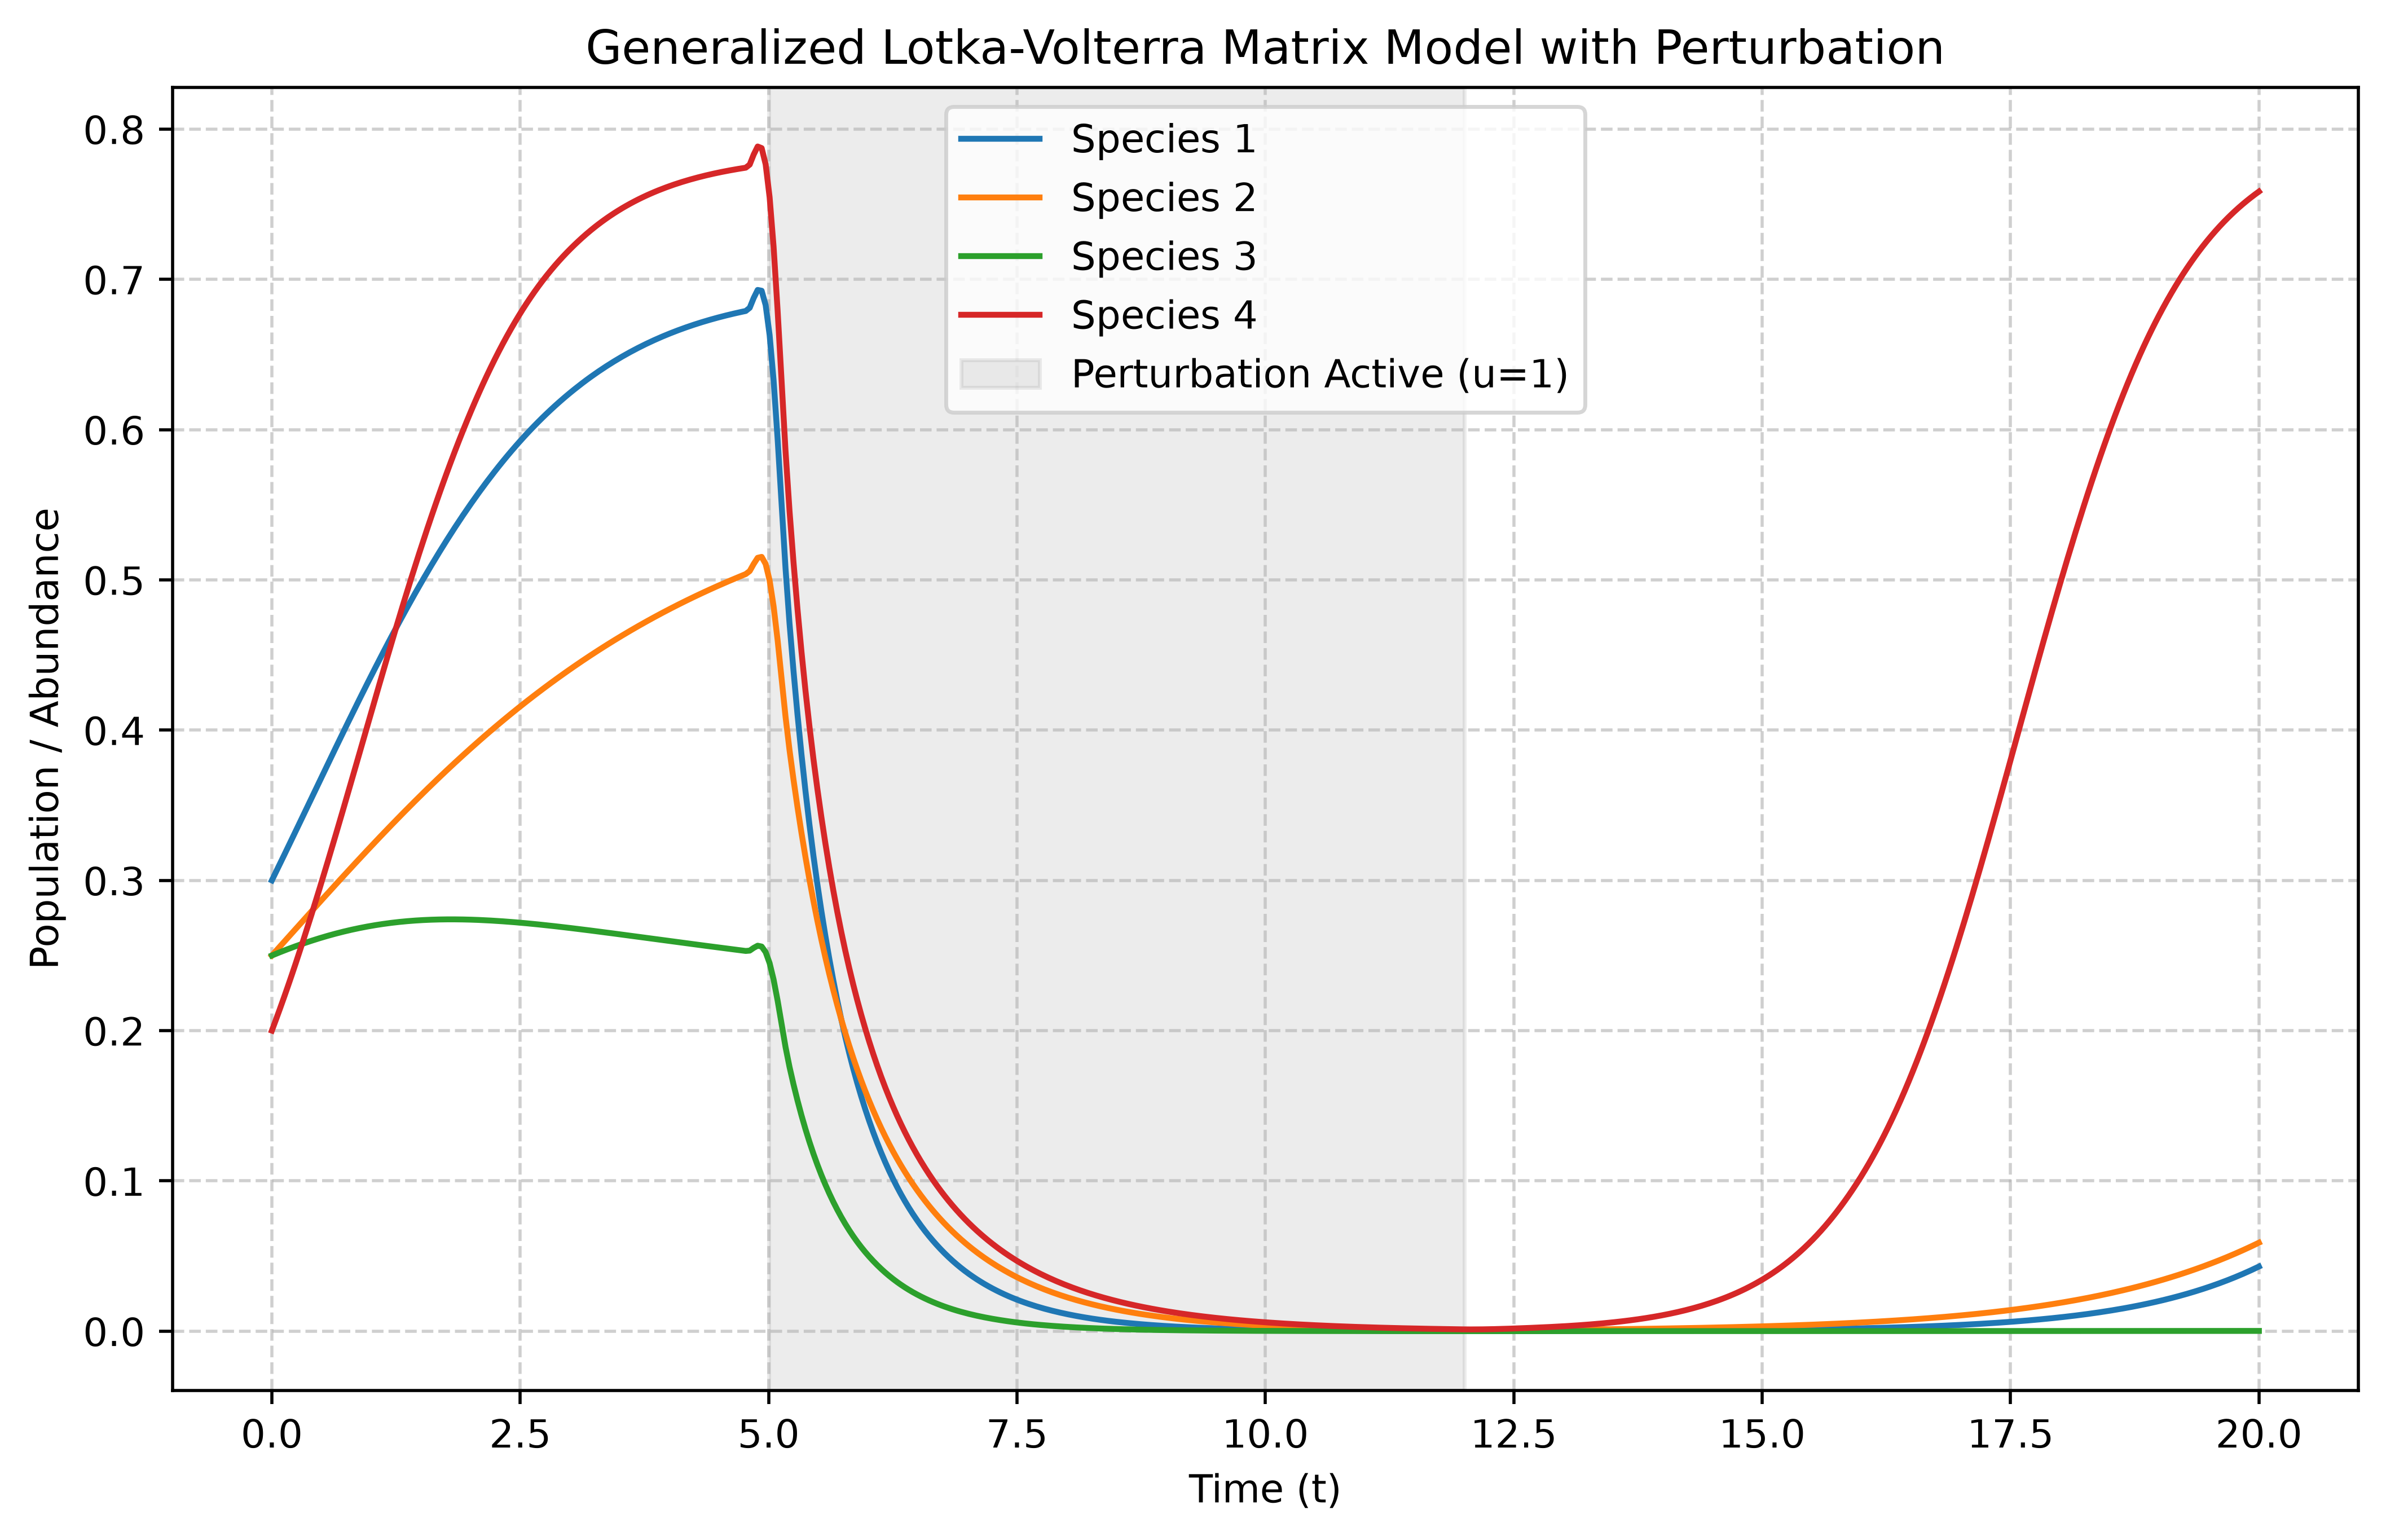

In [11]:
r_growth = np.array([
    0.8,
    0.6,
    0.4,
    1.2
])

A = np.array([
    [ -1.0,  -0.2,  0.0,  0.0],
    [-0.1, -0.8,  -0.3,  0.0],
    [ 0.0,  -0.1,  -0.9,  -0.2],
    [ 0.0,  0.0, -0.1, -1.5]
])

B = np.array(
    [-2.0,
    -1.5,
    -1.8,
    -2.0]
)

# Initial conditions
x_init = np.array([
    0.3,
    0.25,
    0.25,
    0.2
])


def x_prime(t, x, r, A, B):
    u = 1.0 if 5 <= t <= 12 else 0.0

    dxdt = x * (r + A @ x + B * u)
    return dxdt

# 3. Simulation parameters
t_span = (0, 20)
t_eval = np.linspace(0, 20, 500)

# 4. Solve the IVP
# We pass r, A, and B through the args tuple
sol = solve_ivp(
    x_prime, 
    t_span, 
    x_init, 
    args=(r_growth, A, B), 
    t_eval=t_eval
)

# 5. Plot results to see the effect of the perturbation
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(sol.t, sol.y[i], label=f"Species {i+1}")

# Highlight the perturbation window
plt.axvspan(5, 12, color='gray', alpha=0.15, label='Perturbation Active (u=1)')

plt.title("Generalized Lotka-Volterra Matrix Model with Perturbation")
plt.xlabel("Time (t)")
plt.ylabel("Population / Abundance")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Exercise 3

In [12]:
from sklearn.linear_model import Ridge

In [14]:
# 1. Prepare data from your simulation (sol.t and sol.y)
# We use all time points except the last to compute finite differences
t = sol.t[:-1]
dt = np.diff(sol.t)
x_t = sol.y[:, :-1].T  # Shape: (M, n)
x_next = sol.y[:, 1:].T

# 2. Compute the target z_i: log-derivatives
# Adding a small epsilon to avoid log(0) if populations crash
eps = 1e-9
z = (np.log(x_next + eps) - np.log(x_t + eps)) / dt[:, np.newaxis]

# 3. Construct the feature matrix Phi: [x, u]
# Define u for each time step in t
u = np.array([1.0 if 5 <= time <= 12 else 0.0 for time in t]).reshape(-1, 1)
Phi = np.hstack([x_t, u])

# 4. Perform Ridge Regression for each taxon
# r_i is handled by fit_intercept=True
lambda_val = 1.0
model = Ridge(alpha=lambda_val, fit_intercept=True)
model.fit(Phi, z)

# 5. Extract recovered parameters
r_recovered = model.intercept_
A_recovered = model.coef_[:, :-1]
B_recovered = model.coef_[:, -1]

# 6. Compare with ground truth
print("Recovery Error (Recovered - True):")
print("r error:\n", r_recovered - r_growth)
print("\nA error:\n", A_recovered - A)
print("\nB error:\n", B_recovered - B)

Recovery Error (Recovered - True):
r error:
 [-0.04247542 -0.03483368 -0.05430305 -0.07273069]

A error:
 [[ 0.31972963 -0.29273984 -0.16151309  0.04463098]
 [-0.33311924  0.42290615  0.11970133  0.03081044]
 [-0.24021323 -0.13158688  0.67295064  0.10949247]
 [-0.07311379 -0.12519539  0.18271603  0.17959515]]

B error:
 [0.06074972 0.03697128 0.07161823 0.08677895]


# Exercise 4

In [21]:
tblqpcr = pd.read_csv("counts/tblqpcr.csv")
tblcounts_class_wide = pd.read_csv("counts/tblcounts_class_wide.csv")
tbldrug = pd.read_csv("meta_data/tbldrug.csv")

C:\Users\aeriab\AppData\Local\Temp\ipykernel_17196\3893599857.py:3: DtypeWarning: Columns (0: PatientID) have mixed types. Specify dtype option on import or set low_memory=False.
  tbldrug = pd.read_csv("meta_data/tbldrug.csv")
